In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(cv2.__version__)

5.0.0


In [2]:
from google.colab import files
uploaded= files.upload()


Saving IMG_0055.jpeg to IMG_0055.jpeg


In [3]:
print(uploaded.keys())

dict_keys(['IMG_0055.jpeg'])


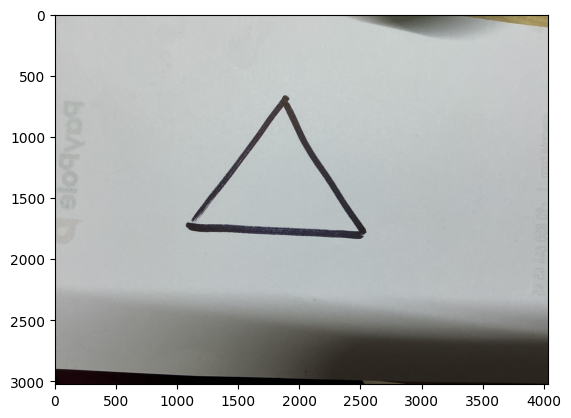

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('IMG_0055.jpeg')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

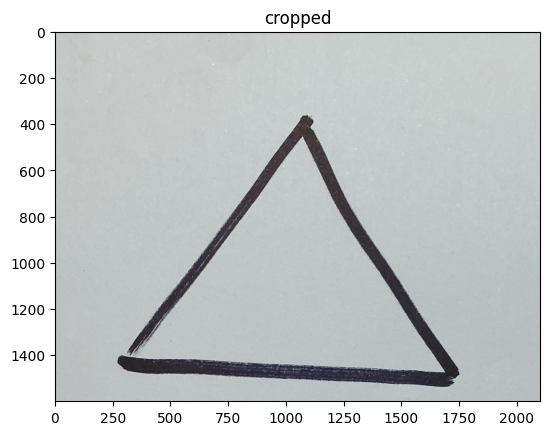

In [13]:
img_cropped=img[300:1900, 800:2900]
img_rgb_cropped=cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb_cropped)
plt.title("cropped")
plt.show()

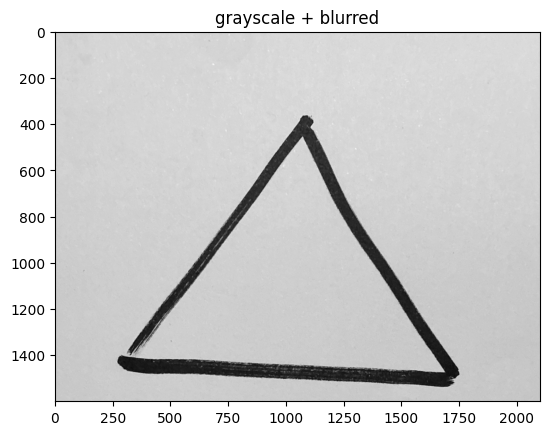

In [14]:
gray=cv2.cvtColor(img_cropped,cv2.COLOR_BGR2GRAY)
blurred=cv2.GaussianBlur(gray, (5,5),0)
plt.imshow(blurred, cmap='gray')
plt.title("grayscale + blurred")
plt.show()

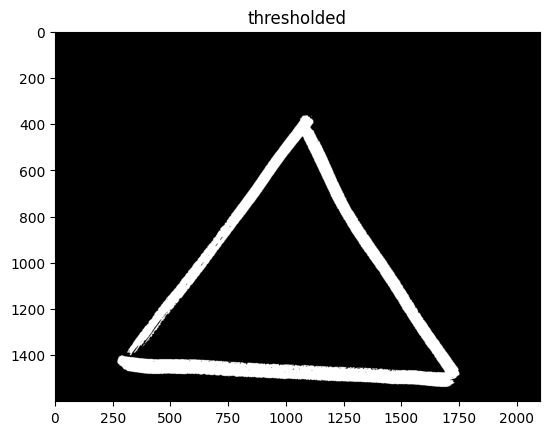

In [15]:
_, thresh=cv2.threshold(blurred, 0, 255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh,cmap='gray')
plt.title("thresholded")
plt.show()

no of contours found =  9
points in largest contour =  3949


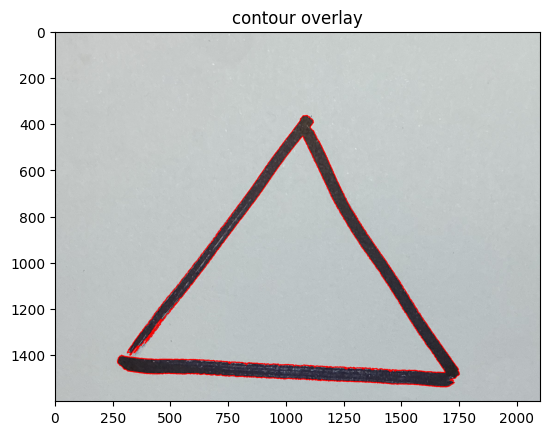

In [16]:
contours, _= cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest=max(contours, key=cv2.contourArea)
print("no of contours found = ", len(contours))
print("points in largest contour = ", len(largest))
img_with_contour=cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB).copy()
cv2.drawContours(img_with_contour, [largest], -1, (255, 0,0), 3)
plt.imshow(img_with_contour)
plt.title("contour overlay")
plt.show()